# 1. Knowledge Graph Construction & Visualization

**Part of the AlzRAGBench notebook series** (`Diffusion_AlzRAGBench_v2.0/`), which builds
and ablation-tests VectorRAG vs GraphRAG vs HybridRAG on a 31-document Alzheimer's
disease corpus, using a locally-hosted **diffusion LLM** (not a standard autoregressive
model) for answer generation.

**This notebook does not need a GPU.** It only loads two CSV files and builds/visualizes
a graph with NetworkX and pyvis — everything here runs in seconds on a CPU.

## What this notebook does

The entity-relation knowledge graph for this project was **already extracted** during
dataset construction: every node and edge in `../Dataset/Knowledge graph/nodes.csv` and
`edges.csv` was curated by reading all 31 source documents (20 PubMed abstracts, 10
Wikipedia articles, 1 StatPearls textbook chapter) and grounding each relation in the
actual text, with a citation back to the source article(s). **We are not re-extracting
anything here** — this notebook's job is to:

1. Load that already-extracted graph data into pandas.
2. Build an in-memory graph object with **NetworkX** (no Neo4j — with only 54 nodes and
   89 edges, a full graph database is unnecessary overhead; NetworkX handles graphs of
   this size trivially and lets every downstream notebook stay dependency-light and
   fully self-contained).
3. Compute structural statistics (degree distribution, connectivity, centrality) that
   tell us which entities are the most important "hubs" for multi-hop retrieval.
4. Produce a static visualization (matplotlib, for a quick printable overview) and an
   interactive visualization (pyvis, for exploring the graph by hovering/dragging nodes).

Notebooks 2–4 will each **rebuild this same graph directly from the CSVs** rather than
depending on any file this notebook produces — that keeps every notebook in this series
independently runnable, at the small cost of a few duplicated lines of graph-building
code.


## 1.1 Imports and paths

We use:
- `pandas` to load the two CSV files
- `networkx` to build and analyze the graph
- `matplotlib` for a static plot
- `pyvis` for an interactive HTML plot (rendered inline via an `IFrame`)

Paths are relative to this notebook's location
(`Diffusion_AlzRAGBench_v2.0/01_knowledge_graph_construction_and_visualization.ipynb`), so
`../Dataset/Knowledge graph/` points at the dataset built in the earlier phase of this
project. If you've moved this notebook elsewhere, update `DATASET_DIR` below.


In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from pathlib import Path
from pyvis.network import Network
from IPython.display import IFrame, display

DATASET_DIR = Path("Dataset")
KG_DIR = DATASET_DIR / "Knowledge graph"
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

NODES_CSV = KG_DIR / "nodes.csv"
EDGES_CSV = KG_DIR / "edges.csv"

assert NODES_CSV.exists(), f"Expected nodes.csv at {NODES_CSV.resolve()}"
assert EDGES_CSV.exists(), f"Expected edges.csv at {EDGES_CSV.resolve()}"
print("Found:", NODES_CSV.resolve())
print("Found:", EDGES_CSV.resolve())


Found: /teamspace/studios/this_studio/AlzRAGBench/Dataset/Knowledge graph/nodes.csv
Found: /teamspace/studios/this_studio/AlzRAGBench/Dataset/Knowledge graph/edges.csv


## 1.2 Load and inspect the raw tables

`nodes.csv` columns (Neo4j-admin-import naming convention, kept as-is even though we're
not using Neo4j — it's a self-documenting, tool-agnostic CSV schema):

- `nodeId:ID` — unique entity identifier, e.g. `AmyloidBeta`, `APOE_e4`
- `name` — human-readable entity name
- `type:LABEL` — entity category, e.g. `Disease`, `Protein`, `Drug`, `RiskFactor`
- `description` — one-line grounded description of the entity

`edges.csv` columns:

- `:START_ID`, `:END_ID` — the two `nodeId:ID` values the edge connects
- `:TYPE` — the relation, e.g. `TREATS`, `RISK_FACTOR_FOR`, `MUTATION_CAUSES`
- `source_articles` — semicolon-separated `article_id` values (matching files in
  `../Dataset/Selected articles/`) that this edge's relation is grounded in
- `evidence` — a short paraphrased justification for the edge, traceable to the source


In [3]:
nodes_df = pd.read_csv(NODES_CSV)
edges_df = pd.read_csv(EDGES_CSV)

print(f"Nodes: {len(nodes_df)}    Edges: {len(edges_df)}")
nodes_df.head()


Nodes: 54    Edges: 89


,nodeId:ID,name,type:LABEL,description
0,AD,Alzheimer's Disease,Disease,Most common cause of dementia worldwide; biolo...
1,Dementia,Dementia,Disease,Umbrella syndrome of acquired cognitive declin...
2,VascularDementia,Vascular Dementia,Disease,"Second most common dementia subtype, driven by..."
3,MixedDementia,Mixed Dementia,Disease,Co-occurrence of more than one dementia pathol...
4,MCI,Mild Cognitive Impairment,Disease,Prodromal cognitive decline stage; amnestic MC...


In [4]:
edges_df.head()


,:START_ID,:END_ID,:TYPE,source_articles,evidence
0,AmyloidPlaques,AD,HALLMARK_OF,pubmed_30135715;pubmed_33986301,AD is biologically defined by beta-amyloid pla...
1,NFT,AD,HALLMARK_OF,pubmed_30135715;pubmed_33986301;pubmed_21371747,Neurofibrillary tangles of hyperphosphorylated...
2,AmyloidBeta,AmyloidPlaques,AGGREGATES_INTO,wikipedia_amyloid_beta,Amyloid-beta oligomers aggregate into fibrils ...
3,TauProtein,NFT,HYPERPHOSPHORYLATED_TO_FORM,wikipedia_tau_protein,Hyperphosphorylation converts normally microtu...
4,NFT,TauProtein,COMPOSED_OF,wikipedia_neurofibrillary_tangle,Neurofibrillary tangles are composed largely o...


## 1.3 Node type and relation type distributions

Before building the graph object, it's worth seeing what kinds of entities and
relations make up this knowledge graph -- this previews what GraphRAG in Notebook 2
will actually be traversing.


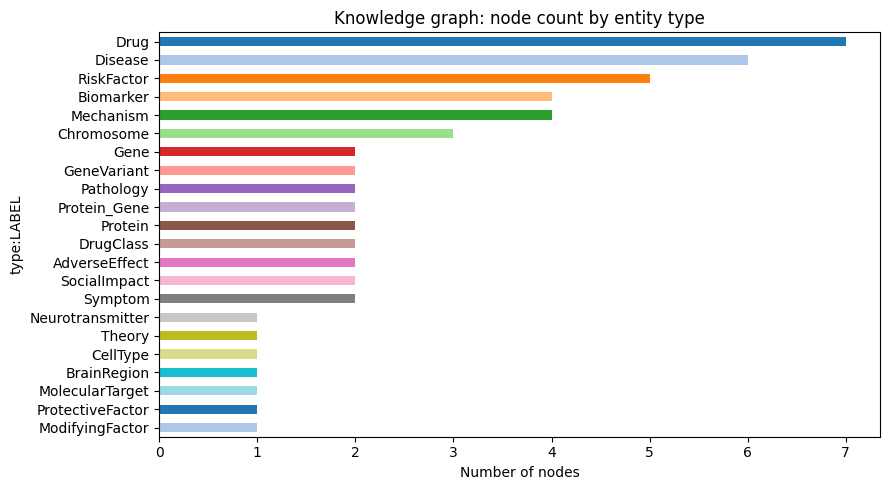


22 distinct node types across 54 nodes.


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
type_counts = nodes_df["type:LABEL"].value_counts()
type_counts.plot(kind="barh", ax=ax, color=plt.cm.tab20.colors[: len(type_counts)])
ax.set_xlabel("Number of nodes")
ax.set_title("Knowledge graph: node count by entity type")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n{len(type_counts)} distinct node types across {len(nodes_df)} nodes.")


In [6]:
print(f"{edges_df[':TYPE'].nunique()} distinct relation types across {len(edges_df)} edges.\n")
print("Most common relations:")
edges_df[":TYPE"].value_counts().head(10)


54 distinct relation types across 89 edges.

Most common relations:


:TYPE
RISK_FACTOR_FOR          6
MEMBER_OF_CLASS          6
TREATS                   4
INTERACTS_WITH           4
MUTATION_CAUSES          3
PROTECTIVE_FACTOR_FOR    3
CONTRIBUTES_TO           3
MEASURES                 3
LOCATED_ON               3
CAUSES                   3
Name: count, dtype: int64

## 1.4 Build the graph with NetworkX

We use a **`MultiDiGraph`** (directed, multi-edge):

- **Directed**, because relations like `TREATS` or `MUTATION_CAUSES` have a clear
  subject -> object direction that matters for retrieval (e.g. "what treats AD" is a
  different query from "what does AD treat").
- **Multi-edge**, because in principle two entities could be connected by more than one
  distinct relation type (e.g. two drugs could both `MEMBER_OF_CLASS` a drug class *and*
  interact some other way) — a plain `DiGraph` would silently overwrite one edge with
  the other.

Every node keeps its `name`, `type`, and `description` as attributes; every edge keeps
its `relation`, `source_articles`, and `evidence` as attributes, so nothing from the
CSVs is lost when we move into graph form.


In [7]:
G = nx.MultiDiGraph()

for _, row in nodes_df.iterrows():
    G.add_node(
        row["nodeId:ID"],
        name=row["name"],
        type=row["type:LABEL"],
        description=row["description"],
    )

for _, row in edges_df.iterrows():
    G.add_edge(
        row[":START_ID"],
        row[":END_ID"],
        relation=row[":TYPE"],
        source_articles=row["source_articles"],
        evidence=row["evidence"],
    )

print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Graph built: 54 nodes, 89 edges


## 1.5 Connectivity check

A knowledge graph riddled with disconnected "islands" of entities is much less useful
for GraphRAG, since multi-hop retrieval can only traverse within a connected component.
This graph was deliberately curated to avoid that -- let's confirm it.


In [8]:
undirected = G.to_undirected()
components = list(nx.connected_components(undirected))
largest = max(components, key=len)

print(f"Connected components: {len(components)}")
print(f"Largest component size: {len(largest)} / {G.number_of_nodes()} nodes")

isolated = list(nx.isolates(G))
print(f"Isolated nodes (no edges at all): {isolated if isolated else 'none'}")


Connected components: 1
Largest component size: 54 / 54 nodes
Isolated nodes (no edges at all): none


## 1.6 Centrality analysis: which entities are the graph's "hubs"?

Two standard centrality measures tell us different things about node importance:

- **Degree centrality** — how many direct connections a node has. High-degree nodes
  (like `AD` itself) are natural entry points for entity linking.
- **Betweenness centrality** — how often a node sits on the shortest path between two
  *other* nodes. High-betweenness nodes are the "bridges" that multi-hop GraphRAG
  retrieval depends on to connect otherwise-distant concepts (e.g. connecting a genetics
  question to a treatment question).

We compute both on the undirected version of the graph, since "importance as a bridge"
doesn't depend on edge direction here.


In [9]:
degree_centrality = nx.degree_centrality(undirected)
betweenness_centrality = nx.betweenness_centrality(undirected)

top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 nodes by degree centrality (most directly connected):")
for node_id, score in top_degree:
    print(f"  {node_id:30s} {score:.3f}   ({G.nodes[node_id]['name']})")

print("\nTop 10 nodes by betweenness centrality (most important 'bridge' entities):")
for node_id, score in top_betweenness:
    print(f"  {node_id:30s} {score:.3f}   ({G.nodes[node_id]['name']})")


Top 10 nodes by degree centrality (most directly connected):
  AD                             0.623   (Alzheimer's Disease)
  AmyloidBeta                    0.132   (Amyloid-beta (Abeta))
  CholinesteraseInhibitors       0.113   (Cholinesterase Inhibitors)
  VascularDementia               0.094   (Vascular Dementia)
  MCI                            0.094   (Mild Cognitive Impairment)
  TauProtein                     0.094   (Tau Protein)
  APOE                           0.094   (Apolipoprotein E (APOE))
  AntiAmyloidAntibodies          0.094   (Anti-Amyloid Monoclonal Antibodies)
  Dementia                       0.075   (Dementia)
  AmyloidPlaques                 0.075   (Amyloid Plaques)

Top 10 nodes by betweenness centrality (most important 'bridge' entities):
  AD                             0.862   (Alzheimer's Disease)
  CholinesteraseInhibitors       0.176   (Cholinesterase Inhibitors)
  AmyloidPlaques                 0.056   (Amyloid Plaques)
  NFT                            0.

## 1.7 Static visualization

A spring layout (force-directed) plot, colored by node type, with node size scaled by
degree (so hub entities visually stand out). This is the quickest way to eyeball the
graph's overall shape and confirm it's densely interconnected rather than a scattering
of disconnected pairs.


/tmp/ipykernel_5753/2217752613.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("tab20", len(node_types))


Saved static plot -> /teamspace/studios/this_studio/AlzRAGBench/artifacts/knowledge_graph_static.png


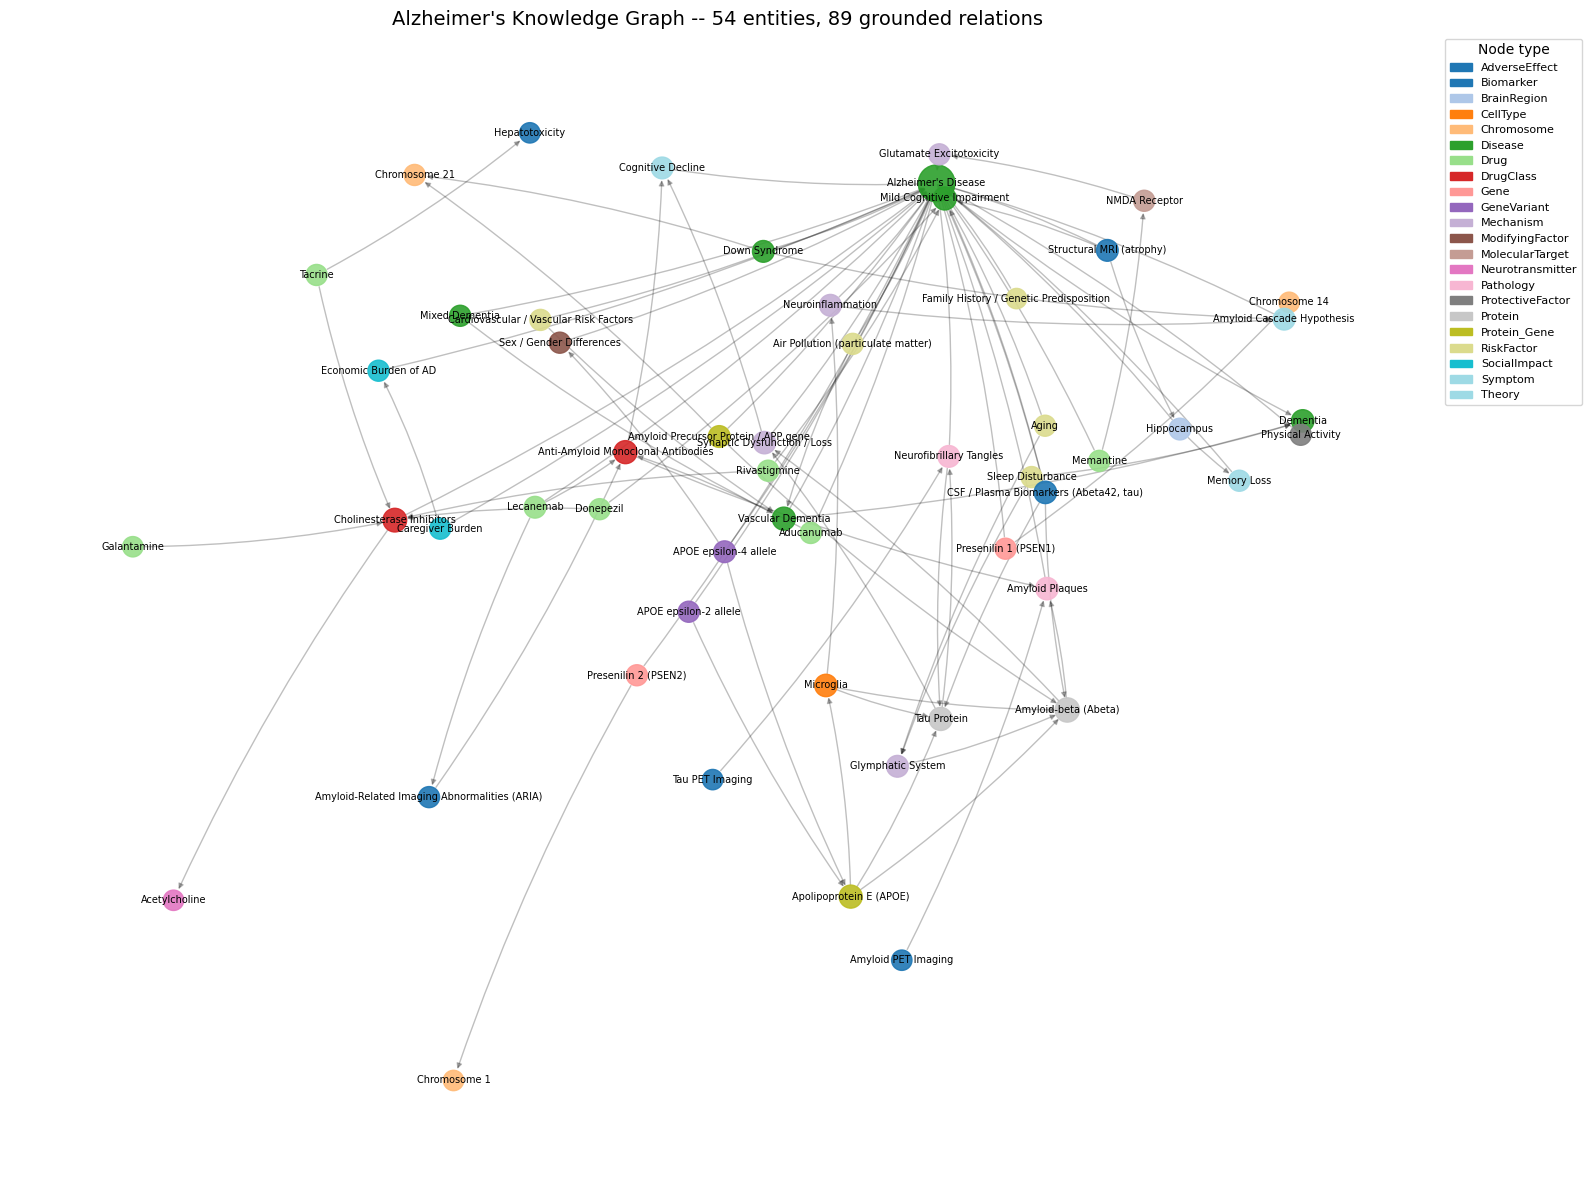

In [10]:
node_types = sorted(nodes_df["type:LABEL"].unique())
cmap = plt.cm.get_cmap("tab20", len(node_types))
type_to_color = {t: cmap(i) for i, t in enumerate(node_types)}

node_colors = [type_to_color[G.nodes[n]["type"]] for n in G.nodes]
node_sizes = [200 + 800 * degree_centrality[n] for n in G.nodes]

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42, k=0.6)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.25, arrows=True, arrowsize=8, connectionstyle="arc3,rad=0.05")
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]["name"] for n in G.nodes}, font_size=7)

legend_handles = [mpatches.Patch(color=type_to_color[t], label=t) for t in node_types]
plt.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, title="Node type")
plt.title("Alzheimer's Knowledge Graph -- 54 entities, 89 grounded relations", fontsize=14)
plt.axis("off")
plt.tight_layout()

static_path = ARTIFACTS_DIR / "knowledge_graph_static.png"
plt.savefig(static_path, dpi=150, bbox_inches="tight")
print(f"Saved static plot -> {static_path.resolve()}")
plt.show()


## 1.8 Interactive visualization (pyvis)

The static plot is good for a quick overview, but with 54 nodes and 89 edges it's hard
to read every label at once. pyvis renders an interactive HTML graph (physics-based
layout, draggable nodes, hover tooltips showing each entity's description and each
edge's relation + evidence) that's much easier to actually explore.

We use `cdn_resources="in_line"` so the resulting HTML file embeds its own JS/CSS and
works fully offline -- consistent with keeping this project's artifacts self-contained.


In [11]:
net = Network(height="800px", width="100%", directed=True, notebook=True, cdn_resources="in_line")
net.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=150)

for node_id, data in G.nodes(data=True):
    net.add_node(
        node_id,
        label=data["name"],
        title=f"<b>{data['name']}</b> ({data['type']})<br>{data['description']}",
        color=f"rgba({int(type_to_color[data['type']][0]*255)},"
              f"{int(type_to_color[data['type']][1]*255)},"
              f"{int(type_to_color[data['type']][2]*255)},1)",
    )

for start, end, data in G.edges(data=True):
    net.add_edge(
        start,
        end,
        title=f"<b>{data['relation']}</b><br>{data['evidence']}<br><i>source: {data['source_articles']}</i>",
        arrows="to",
    )

interactive_path = ARTIFACTS_DIR / "knowledge_graph_interactive.html"
# pyvis's own write_html() opens the file without specifying an encoding, which
# defaults to the system codepage (cp1252 on Windows) and breaks on non-ASCII
# characters. We generate the HTML string ourselves and write it explicitly as
# UTF-8 to keep this notebook portable across platforms.
html_content = net.generate_html(notebook=True)
interactive_path.write_text(html_content, encoding="utf-8")
print(f"Saved interactive graph -> {interactive_path.resolve()}")

display(IFrame(src=str(interactive_path), width="100%", height="820px"))


Saved interactive graph -> /teamspace/studios/this_studio/AlzRAGBench/artifacts/knowledge_graph_interactive.html


## 1.9 (Optional) Export to GraphML

`networkx` can serialize the graph to GraphML, a standard format readable by Gephi,
Cytoscape, or `nx.read_graphml` in another notebook/script. This is purely a
convenience export for external tools -- **notebooks 2 and 4 do not depend on this
file**; they rebuild the graph directly from `nodes.csv`/`edges.csv` themselves so each
notebook in this series stays independently runnable.


In [12]:
graphml_path = ARTIFACTS_DIR / "alzheimers_kg.graphml"
nx.write_graphml(G, graphml_path)
print(f"Saved GraphML export -> {graphml_path.resolve()} (optional, not required by other notebooks)")


Saved GraphML export -> /teamspace/studios/this_studio/AlzRAGBench/artifacts/alzheimers_kg.graphml (optional, not required by other notebooks)


## Summary

- Loaded the pre-extracted knowledge graph (54 nodes / 89 edges) from
  `../Dataset/Knowledge graph/`.
- Built it as a NetworkX `MultiDiGraph` -- no Neo4j required at this scale.
- Confirmed **zero isolated nodes** and a single connected component: every entity is
  reachable from every other entity, which is what makes multi-hop GraphRAG traversal
  (Notebook 2) meaningful rather than a lookup over disconnected fact islands.
- Identified hub entities via degree and betweenness centrality (`AD`, `AmyloidBeta`,
  and `TauProtein` are expected to rank highly, given how many other concepts in this
  corpus connect back to them).
- Produced a static overview plot and a fully offline-capable interactive HTML graph in
  `artifacts/`.

**Next:** [`02_graphrag_pipeline_and_retrieval_methods.ipynb`](02_graphrag_pipeline_and_retrieval_methods.ipynb)
rebuilds this same graph and implements four different retrieval strategies over it,
paired with a locally-hosted diffusion LLM for answer generation.
